# Import lib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
torch.__version__

'2.6.0+cu124'

In [ ]:
torchvision.__version__

'0.21.0+cu124'

# 2. Setup Device-Agnostic Code

In [ ]:
!nvidia-smi

Wed Jul 23 03:14:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
torch.cuda.is_available()

True

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
print(f"Using Device: {device}")

Using Device: cuda


# 3. Set the seed

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

# 4. Set hyperparameters

In [ ]:
3e-4

0.0003

In [ ]:
BATCH_SIZE = 128
EPOCHS = 10 # Try increasing epochs to 30
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32 # Transform the image and make the size go to 224
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8 # INcrease the number heads
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

# 5. Define Image Transformations

In [170]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
    # 1. Helps the model to converge faster
    # 2. Helps to make the numerical computations stable
])

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

# 6. Getting a dataset

In [171]:
train_dataset = datasets.CIFAR10(root="data",
                                 train=True,
                                 download=True,
                                 transform=transform_train)

In [172]:
test_dataset = datasets.CIFAR10(root="data",
                                train=False,
                                download=True,
                                transform=transform_train)

In [173]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.2, 0.2))
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [174]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.2, 0.2))
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [175]:
len(train_dataset), len(test_dataset)

(50000, 10000)

# Converting out datasets into dataloaders

In [176]:
BATCH_SIZE

128

In [177]:
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

In [178]:
# Let's check out what we've created
print(f"DataLoader: {train_loader, test_loader}")
print(f"Length of train_loader: {len(train_loader)} batches of {BATCH_SIZE}...")
print(f"Length of test_loader: {len(test_loader)} batches of {BATCH_SIZE}...")

DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x7ba1682a8690>, <torch.utils.data.dataloader.DataLoader object at 0x7ba16827f4d0>)
Length of train_loader: 391 batches of 128...
Length of test_loader: 79 batches of 128...


# 8. ViT From Scratch

In [179]:
PATCH_SIZE

4

In [180]:
class PatchEmbedding(nn.Module):
  def __init__(self,
               img_size,
               patch_size,
               in_channels,
               embed_dim):
    super().__init__()
    self.patch_size = patch_size
    self.proj = nn.Conv2d(in_channels = in_channels,
                          out_channels = embed_dim,
                          kernel_size = patch_size,
                          stride = patch_size)
    num_patches = (img_size//patch_size)**2
    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
    self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

  def forward(self, x:torch.Tensor):
    B = x.size(0)
    x = self.proj(x) # (B, E, H/P, W/P)
    x = x.flatten(2).transpose(1,2) # (B, N, E)
    cls_token = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_token, x), dim = 1)
    x = x+ self.pos_embed
    return x

In [181]:
# test = PatchEmbedding(IMAGE_SIZE, PATCH_SIZE, CHANNELS, EMBED_DIM)

In [182]:
class MLP(nn.Module):
  def __init__(self,
               in_features,
               hidden_features,
               drop_rate):
    super().__init__()
    self.fc1 = nn.Linear(in_features=in_features, out_features=hidden_features)
    self.fc2 = nn.Linear(in_features = hidden_features, out_features = in_features)
    self.dropout = nn.Dropout(drop_rate)

  def forward(self, x):
    x = self.dropout(F.gelu(self.fc1(x)))
    x = self.dropout(self.fc2(x))
    return x

In [183]:
# test = MLP(in_features=EMBED_DIM, hidden_features=MLP_DIM, drop_rate=DROP_RATE)

In [184]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self,
               embed_dim,
               num_heads,
               mlp_dim,
               drop_rate):
    super().__init__()
    self.norm1 = nn.LayerNorm(embed_dim)
    self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout = drop_rate, batch_first=True)
    self.norm2 = nn.LayerNorm(embed_dim)
    self.mlp = MLP(in_features=embed_dim, hidden_features=mlp_dim, drop_rate=drop_rate)

  def forward(self, x):
    x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
    x = x + self.mlp(self.norm2(x))
    return x

In [185]:
# test = TransformerEncoderLayer(embed_dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_dim=MLP_DIM, drop_rate=DROP_RATE)

In [186]:
class VisionTransformer(nn.Module):
  def __init__(self, img_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate):
    super().__init__()
    self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
    self.encoder = nn.Sequential(*[
            TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate)
            for _ in range(depth)
        ])
    self.norm = nn.LayerNorm(embed_dim)
    self.head = nn.Linear(embed_dim, num_classes)

  def forward(self, x):
    x = self.patch_embed(x)
    x = self.encoder(x)
    x = self.norm(x)
    cls_token = x[:,0]
    return self.head(cls_token)

In [187]:
# Instantiate model
# Pass about IMAGE_SIZE, PATCH_SIZE, CHANNELS, NUM_CLASSES, EMBED_DIM, DEPTH
model = VisionTransformer(
    img_size = IMAGE_SIZE,
    patch_size = PATCH_SIZE,
    in_channels = CHANNELS,
    num_classes = NUM_CLASSES,
    embed_dim = EMBED_DIM,
    depth = DEPTH,
    num_heads = NUM_HEADS,
    mlp_dim = MLP_DIM,
    drop_rate = DROP_RATE
).to(device)

In [188]:
model

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP

# 9. Defining a loss function and optimizer

In [189]:
criterion = nn.CrossEntropyLoss() # Measure how wrong our model is
optimizer = torch.optim.Adam(params=model.parameters(), # update our model's parameters to try and reduce the loss
                             lr=LEARNING_RATE)

In [190]:
criterion

CrossEntropyLoss()

In [191]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)

# 10. Defining a traininig loop function

In [192]:
def train(model, loader, optimizer, criterion):
    # Set the mode of the model into training
    model.train()

    total_loss, correct = 0, 0

    for x, y in loader:
        # Moving (Sending) our data into the target device
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        # 1. Forward pass (model outputs raw logits)
        out = model(x)
        # 2. Calcualte loss (per batch)
        loss = criterion(out, y)
        # 3. Perform backpropgation
        loss.backward()
        # 4. Perforam Gradient Descent
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    # You have to scale the loss (Normlization step to make the loss general across all batches)
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [208]:
def evaluate(model, loader):
  model.eval() # Set the mode of the model into evaluation
  correct = 0
  with torch.inference_mode():
    for x, y in loader:
      x, y = x.to(device), y.to(device)
      out = model(x)
      correct += (out.argmax(dim=1) == y).sum().item()

  return correct/len(loader.dataset)


In [209]:
EPOCHS

10

In [210]:
from tqdm.auto import tqdm

In [211]:
### Training
train_accuracies, test_accuracies = [], []

for epoch in tqdm(range(EPOCHS)):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch: {epoch+1}/{EPOCHS}, Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}%, Test acc: {test_acc:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1/10, Train loss: 1.1384, Train acc: 0.5945%, Test acc: 0.5996
Epoch: 2/10, Train loss: 1.1123, Train acc: 0.6005%, Test acc: 0.6109
Epoch: 3/10, Train loss: 1.0871, Train acc: 0.6117%, Test acc: 0.6136
Epoch: 4/10, Train loss: 1.0565, Train acc: 0.6236%, Test acc: 0.6307
Epoch: 5/10, Train loss: 1.0316, Train acc: 0.6329%, Test acc: 0.6405
Epoch: 6/10, Train loss: 1.0091, Train acc: 0.6412%, Test acc: 0.6416
Epoch: 7/10, Train loss: 0.9815, Train acc: 0.6528%, Test acc: 0.6518
Epoch: 8/10, Train loss: 0.9638, Train acc: 0.6565%, Test acc: 0.6527
Epoch: 9/10, Train loss: 0.9370, Train acc: 0.6690%, Test acc: 0.6621
Epoch: 10/10, Train loss: 0.9222, Train acc: 0.6750%, Test acc: 0.6765


In [212]:
train_accuracies

[0.5945,
 0.60054,
 0.61168,
 0.62362,
 0.63294,
 0.64122,
 0.6528,
 0.65652,
 0.66902,
 0.67496]

In [213]:
test_accuracies

[0.5996,
 0.6109,
 0.6136,
 0.6307,
 0.6405,
 0.6416,
 0.6518,
 0.6527,
 0.6621,
 0.6765]

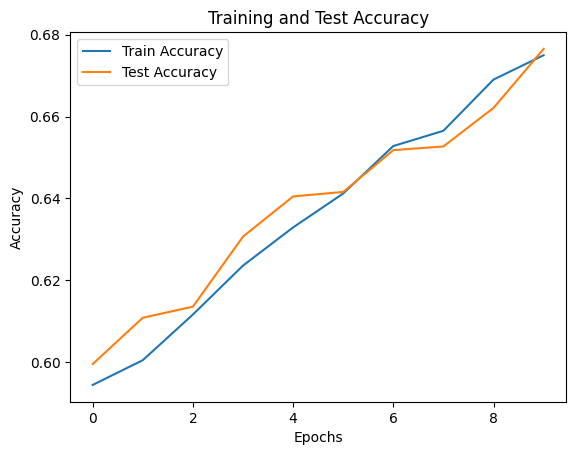

In [214]:
# Plot accuracy
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Test Accuracy")
plt.show()

In [215]:
import random

In [216]:
len(test_dataset)

10000

In [217]:
test_dataset[0][0].unsqueeze(dim=0).shape

torch.Size([1, 3, 32, 32])

In [218]:
test_dataset[0][0] / 2 + 0.5

tensor([[[0.5686, 0.5804, 0.5882,  ..., 0.0039, 0.0039, 0.0039],
         [0.5922, 0.5961, 0.6000,  ..., 0.0039, 0.0039, 0.0039],
         [0.6000, 0.5804, 0.6000,  ..., 0.0039, 0.0039, 0.0039],
         ...,
         [0.1608, 0.1608, 0.1608,  ..., 0.0039, 0.0039, 0.0039],
         [0.0039, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039],
         [0.0039, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039]],

        [[0.1765, 0.1843, 0.1882,  ..., 0.0039, 0.0039, 0.0039],
         [0.1804, 0.1922, 0.2000,  ..., 0.0039, 0.0039, 0.0039],
         [0.1804, 0.1725, 0.1961,  ..., 0.0039, 0.0039, 0.0039],
         ...,
         [0.4706, 0.4667, 0.4314,  ..., 0.0039, 0.0039, 0.0039],
         [0.0039, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039],
         [0.0039, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039]],

        [[0.2510, 0.2314, 0.2353,  ..., 0.0039, 0.0039, 0.0039],
         [0.2588, 0.2510, 0.2471,  ..., 0.0039, 0.0039, 0.0039],
         [0.2510, 0.2314, 0.2431,  ..., 0.0039, 0.0039, 0.

In [219]:
def predict_and_plot_grid(model,
                          dataset,
                          classes,
                          grid_size=3):
    model.eval()
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(9, 9))
    for i in range(grid_size):
        for j in range(grid_size):
            idx = random.randint(0, len(dataset) - 1)
            img, true_label = dataset[idx]
            input_tensor = img.unsqueeze(dim=0).to(device)
            with torch.inference_mode():
                output = model(input_tensor)
                _, predicted = torch.max(output.data, 1)
            img = img / 2 + 0.5 # Unormalize our images to be able to plot them with matplotlib
            npimg = img.cpu().numpy()
            axes[i, j].imshow(np.transpose(npimg, (1, 2, 0)))
            truth = classes[true_label] == classes[predicted.item()]
            if truth:
                color = "g"
            else:
                color = "r"

            axes[i, j].set_title(f"Truth: {classes[true_label]}\n, Predicted: {classes[predicted.item()]}", fontsize=10, c=color)
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()

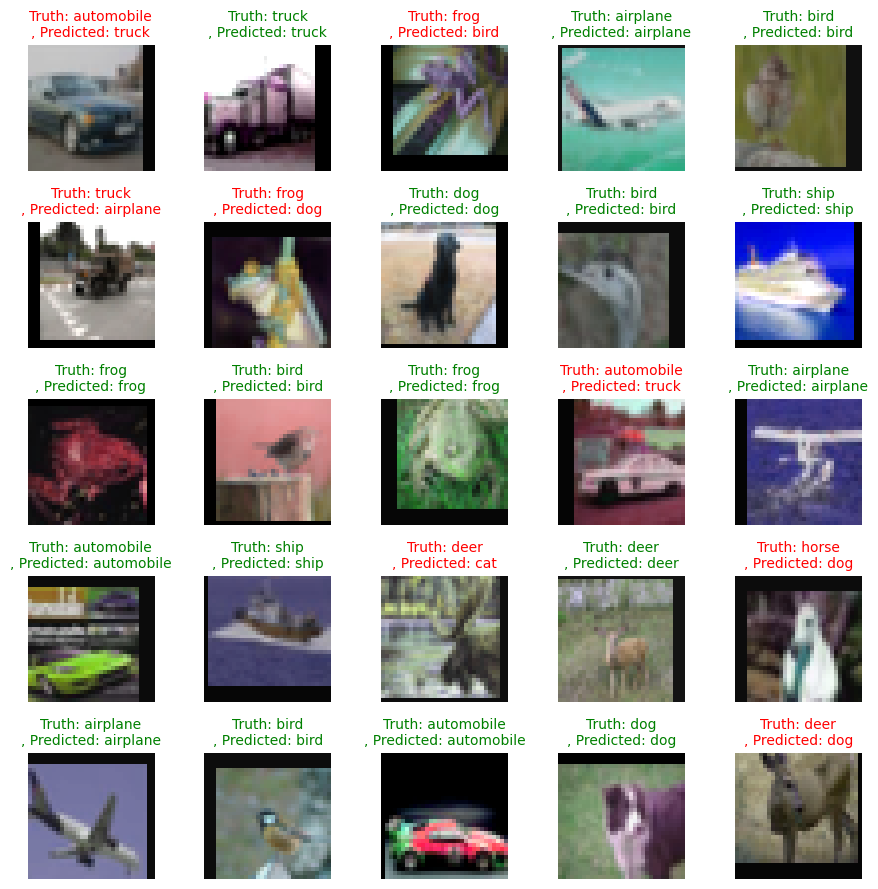

In [220]:
predict_and_plot_grid(model, test_dataset, classes=train_dataset.classes, grid_size=5)